# 01 - Exploratory Data Analysis
**Diabetic Retinopathy Stage Detection - Kaggle 2015 (resized) dataset**

Goals of this notebook (rubric criterion 1 - Problem Understanding & Dataset Justification):
1. Index every image and verify labels against `trainLabels.csv`.
2. Quantify class imbalance.
3. Inspect image properties (resolution, brightness, colour).
4. Look at per-patient structure (left/right eye).
5. Create and save a **patient-level** stratified train/val/test split.

All figures are written to `FIG_DIR` so they can be dropped straight into the report.

In [1]:
# --- Environment bootstrap: works on Kaggle, Ubuntu GPU box and Windows ----
import os, sys, subprocess
from pathlib import Path

REPO = "https://github.com/pradeesha999/dr-stage-detection-v2.git"
if Path("/kaggle/working").exists():
    dst = Path("/kaggle/working/dr_project")
    if not dst.exists():
        try:   # private repo: store a GitHub token as Kaggle secret GITHUB_TOKEN
            from kaggle_secrets import UserSecretsClient
            url = REPO.replace("https://", f"https://{UserSecretsClient().get_secret('GITHUB_TOKEN')}@")
        except Exception:
            url = REPO                      # works as-is if the repo is public
        subprocess.run(["git", "clone", "-q", url, str(dst)], check=True)
    os.chdir(dst / "notebooks")
sys.path.insert(0, str(Path.cwd().parent))     # notebooks/ -> dr_project/

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import cv2
from tqdm.auto import tqdm

from src import config, data, utils
utils.set_seed()
sns.set_theme(style="whitegrid")

print("Data root :", config.DATA_ROOT)
print("Images dir:", config.IMAGE_DIR)
print("Figures ->", config.FIG_DIR)

Data root : C:\Pradeesha_Dev\Computer-vision - final\archive
Images dir: C:\Pradeesha_Dev\Computer-vision - final\archive\colored_images\colored_images
Figures -> C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures


## 1. Index the dataset

In [2]:
df = data.build_dataframe()
print(f"{len(df):,} images from {df.patient_id.nunique():,} patients")
df.head()

35,126 images from 17,563 patients


,image_path,image_id,patient_id,eye,class_name,label
0,C:\Pradeesha_Dev\Computer-vision - final\archi...,10003_left,10003,left,No_DR,0
1,C:\Pradeesha_Dev\Computer-vision - final\archi...,10003_right,10003,right,No_DR,0
2,C:\Pradeesha_Dev\Computer-vision - final\archi...,10007_left,10007,left,No_DR,0
3,C:\Pradeesha_Dev\Computer-vision - final\archi...,10007_right,10007,right,No_DR,0
4,C:\Pradeesha_Dev\Computer-vision - final\archi...,10009_left,10009,left,No_DR,0


## 2. Class distribution

,images,percent
class_name,,
No_DR,25810,73.5
Mild,2443,7.0
Moderate,5292,15.1
Severe,873,2.5
Proliferate_DR,708,2.0


saved C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures\01_class_distribution.png


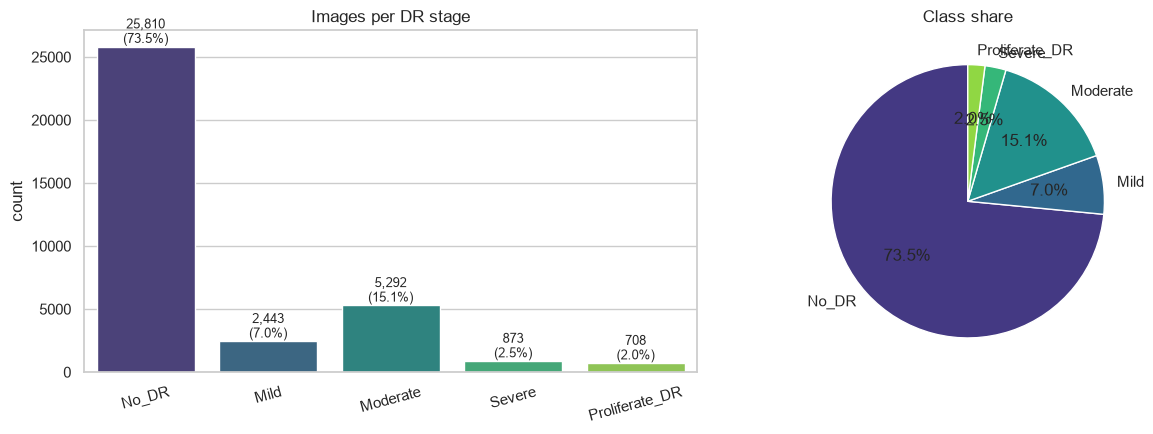

Imbalance ratio (majority/minority): 36.5x


In [3]:
counts = df.class_name.value_counts().reindex(config.CLASS_NAMES)
pct = (counts / counts.sum() * 100).round(1)
summary = pd.DataFrame({"images": counts, "percent": pct})
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette="viridis", legend=False, ax=ax[0])
for i, v in enumerate(counts.values):
    ax[0].text(i, v + 300, f"{v:,}\n({pct.iloc[i]}%)", ha="center", fontsize=9)
ax[0].set(title="Images per DR stage", xlabel="", ylabel="count")
ax[0].tick_params(axis="x", rotation=15)

ax[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90,
          colors=sns.color_palette("viridis", 5))
ax[1].set_title("Class share")
plt.tight_layout(); utils.save_fig("01_class_distribution"); plt.show()

print(f"Imbalance ratio (majority/minority): {counts.max() / counts.min():.1f}x")

**Observation.** The dataset is severely imbalanced: ~73% of images are *No_DR*, while
*Severe* and *Proliferate_DR* together are <5%. A naive classifier that always predicts
No_DR would score ~73% accuracy - so accuracy alone is a misleading metric, and
class balancing (Phase 3) is mandatory.

## 3. Sample images per class

saved C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures\01_samples_per_class.png


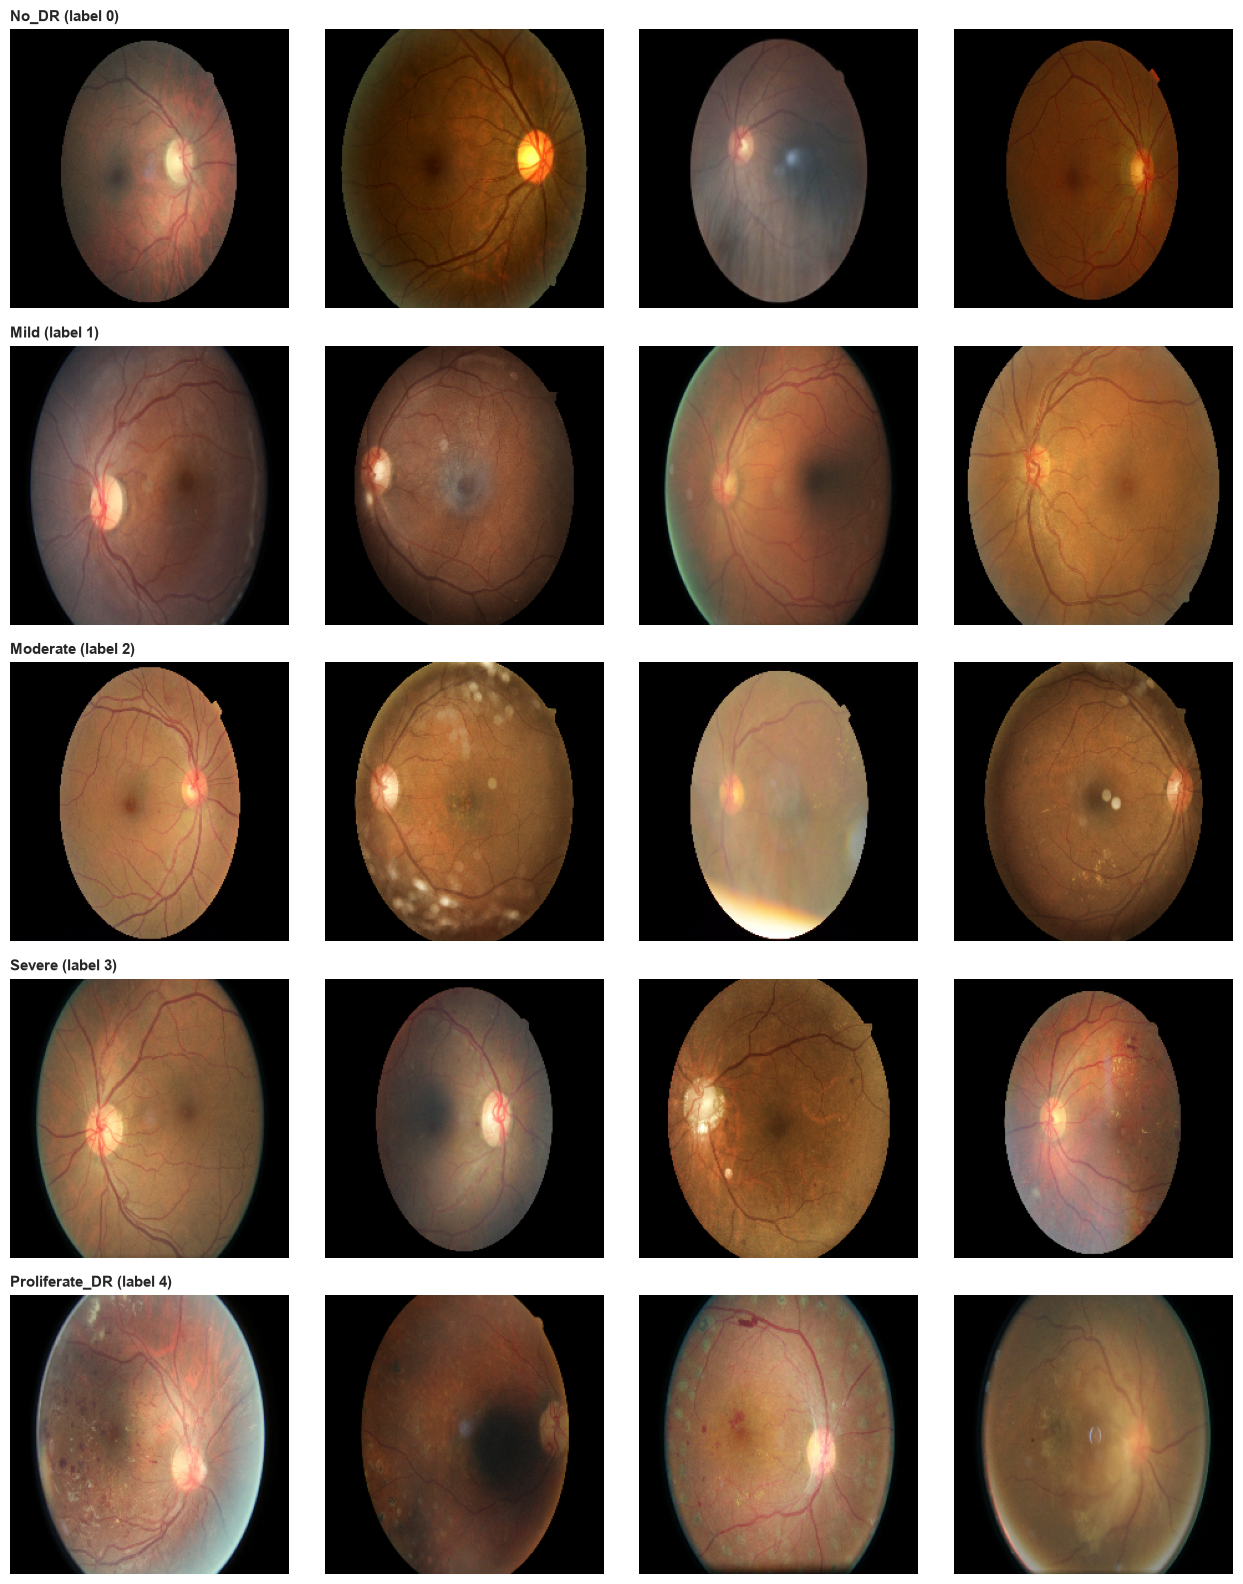

In [4]:
n_per_class = 4
fig, axes = plt.subplots(config.NUM_CLASSES, n_per_class, figsize=(3.2 * n_per_class, 3.2 * config.NUM_CLASSES))
for r, cname in enumerate(config.CLASS_NAMES):
    sample = df[df.class_name == cname].sample(n_per_class, random_state=config.SEED)
    for c, (_, row) in enumerate(sample.iterrows()):
        img = cv2.cvtColor(cv2.imread(row.image_path), cv2.COLOR_BGR2RGB)
        axes[r, c].imshow(img); axes[r, c].axis("off")
        if c == 0:
            axes[r, c].set_title(f"{cname} (label {row.label})", loc="left", fontsize=11, fontweight="bold")
plt.tight_layout(); utils.save_fig("01_samples_per_class"); plt.show()

**Observation.** Lesions that separate the stages (microaneurysms, dot haemorrhages,
hard exudates, neovascularisation) are small and low-contrast at this resolution.
Illumination and colour vary strongly between images (different cameras / clinics),
which motivates contrast normalisation in preprocessing.

## 4. Image properties (resolution, brightness, colour)

  0%|          | 0/1500 [00:00<?, ?it/s]

Unique resolutions (h, w): [[224, 224]]


,mean_r,mean_g,mean_b,mean_gray,dark_frac
class_name,,,,,
No_DR,82.1,57.1,41.2,62.8,0.4
Mild,79.8,54.5,37.8,60.2,0.4
Moderate,80.7,57.5,41.1,62.5,0.4
Severe,82.1,59.4,42.2,64.2,0.4
Proliferate_DR,79.3,55.7,37.5,60.6,0.4


saved C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures\01_image_statistics.png


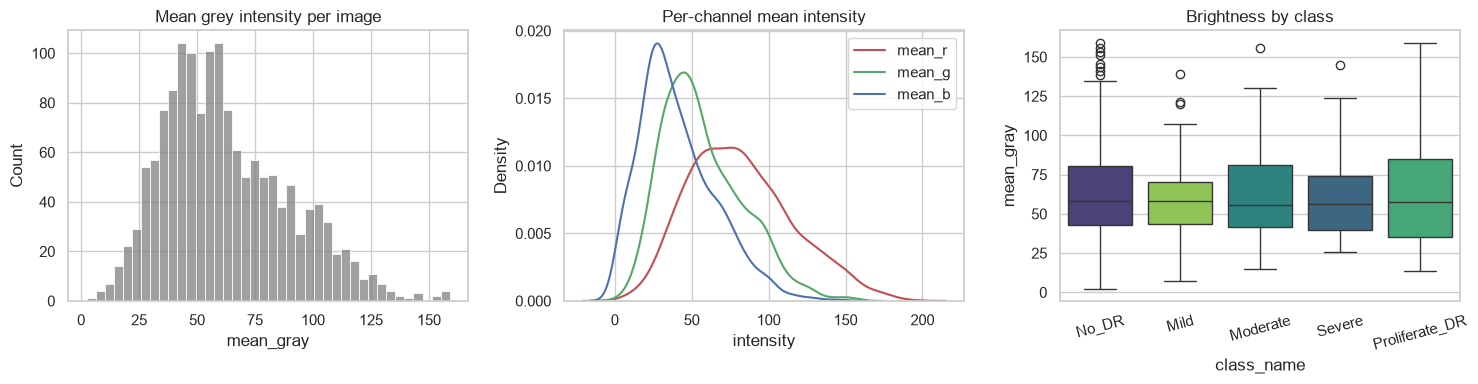

In [5]:
# Sampling keeps this fast; the resized dataset should be uniform anyway.
sample = df.sample(min(1500, len(df)), random_state=config.SEED)
stats = []
for _, row in tqdm(sample.iterrows(), total=len(sample)):
    img = cv2.imread(row.image_path)
    h, w = img.shape[:2]
    b, g, r = cv2.mean(img)[:3]
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    stats.append(dict(label=row.label, class_name=row.class_name, h=h, w=w,
                      mean_r=r, mean_g=g, mean_b=b, mean_gray=gray.mean(),
                      dark_frac=(gray < 10).mean()))   # black border share
stats = pd.DataFrame(stats)

print("Unique resolutions (h, w):", stats[["h", "w"]].drop_duplicates().values.tolist()[:10])
display(stats.groupby("class_name")[["mean_r", "mean_g", "mean_b", "mean_gray", "dark_frac"]].mean().round(1).reindex(config.CLASS_NAMES))

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(stats.mean_gray, bins=40, ax=ax[0], color="gray"); ax[0].set_title("Mean grey intensity per image")
for ch, col in zip(["mean_r", "mean_g", "mean_b"], ["r", "g", "b"]):
    sns.kdeplot(stats[ch], ax=ax[1], color=col, label=ch)
ax[1].set(title="Per-channel mean intensity", xlabel="intensity"); ax[1].legend()
sns.boxplot(data=stats, x="class_name", y="mean_gray", order=config.CLASS_NAMES, ax=ax[2], hue="class_name", palette="viridis", legend=False)
ax[2].set_title("Brightness by class"); ax[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); utils.save_fig("01_image_statistics"); plt.show()

**Observation.** Brightness spans a wide range (dark under-exposed scans to very bright ones)
and the red channel dominates, as expected for fundus photography. The green channel carries
the most vessel/lesion contrast, which is why CLAHE is commonly applied to it. The black
border fraction tells us how much of each frame is wasted background - cropping it
lets the CNN spend its pixels on the retina.

## 5. Patient-level structure (left vs right eye)

Patients with both eyes: 17,563   |   same stage in both eyes: 87.2%


saved C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures\01_left_right_agreement.png


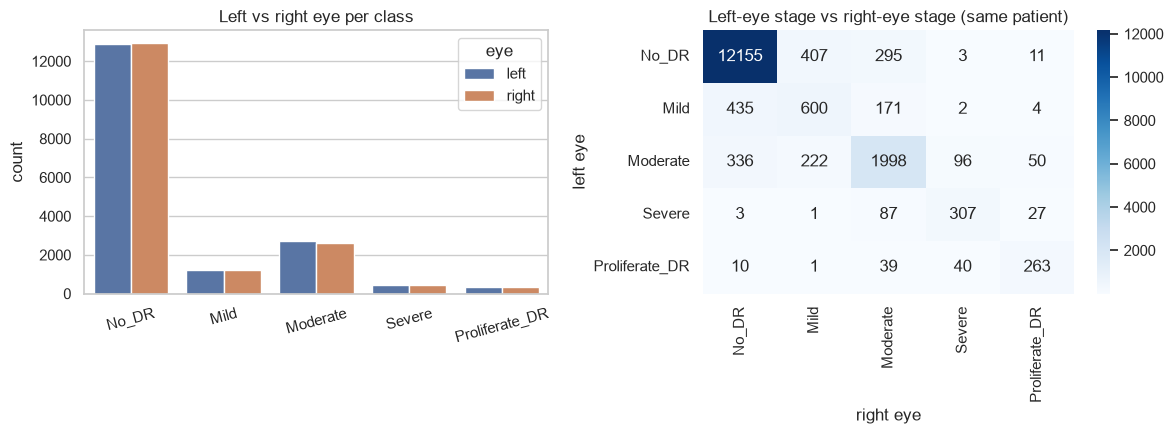

In [6]:
# Are both eyes of a patient usually at the same stage?
eyes = df.pivot_table(index="patient_id", columns="eye", values="label")
both = eyes.dropna()
agree = (both.left == both.right).mean()
print(f"Patients with both eyes: {len(both):,}   |   same stage in both eyes: {agree:.1%}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.countplot(data=df, x="class_name", hue="eye", order=config.CLASS_NAMES, ax=ax[0])
ax[0].set(title="Left vs right eye per class", xlabel=""); ax[0].tick_params(axis="x", rotation=15)

cm = pd.crosstab(both.left.astype(int), both.right.astype(int))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1],
            xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES)
ax[1].set(title="Left-eye stage vs right-eye stage (same patient)", xlabel="right eye", ylabel="left eye")
plt.tight_layout(); utils.save_fig("01_left_right_agreement"); plt.show()

**Observation.** Both eyes of the same patient share the same stage most of the time.
This is exactly why the split must be done **per patient**: if one eye is in the training set
and the other in the test set, the model is effectively tested on data it has already seen
(data leakage), inflating every metric.

## 6. Patient-level stratified split (70 / 15 / 15)

splits saved to C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\splits


,train,val,test,train %,test %
class_name,,,,,
No_DR,18070,3865,3875,73.5,73.5
Mild,1708,367,368,6.9,7.0
Moderate,3704,798,790,15.1,15.0
Severe,611,133,129,2.5,2.4
Proliferate_DR,495,105,108,2.0,2.0
TOTAL,24588,5268,5270,100.0,100.0


saved C:\Pradeesha_Dev\Computer-vision - final\dr_project\outputs\figures\01_split_distribution.png


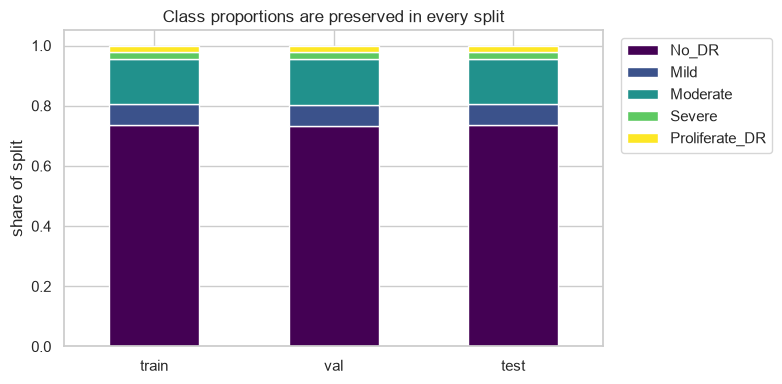

In [7]:
train_df, val_df, test_df = data.patient_split(df)
data.save_splits(train_df, val_df, test_df)

split_tbl = pd.concat({
    "train": train_df.class_name.value_counts(),
    "val":   val_df.class_name.value_counts(),
    "test":  test_df.class_name.value_counts(),
}, axis=1).reindex(config.CLASS_NAMES)
split_tbl.loc["TOTAL"] = split_tbl.sum()
split_tbl["train %"] = (split_tbl.train / split_tbl.train["TOTAL"] * 100).round(1)
split_tbl["test %"]  = (split_tbl.test  / split_tbl.test["TOTAL"]  * 100).round(1)
display(split_tbl)

pct = split_tbl.drop("TOTAL")[["train", "val", "test"]]
pct = pct / pct.sum()
pct.T.plot(kind="bar", stacked=True, colormap="viridis", figsize=(8, 4))
plt.ylabel("share of split"); plt.title("Class proportions are preserved in every split")
plt.legend(bbox_to_anchor=(1.02, 1)); plt.xticks(rotation=0)
plt.tight_layout(); utils.save_fig("01_split_distribution"); plt.show()

## 7. Key take-aways for the report

| Finding | Consequence for the pipeline |
|---|---|
| 35,126 images / 17,563 patients, 5 ordinal stages | Multi-class classification; QWK is a natural extra metric |
| 73% No_DR, 2% PDR (36x imbalance) | Class weights + oversampling; report macro-F1, not accuracy |
| Strong brightness / colour variation | CLAHE + normalisation in preprocessing |
| Black borders waste pixels | Crop to retina before resizing |
| Both eyes of a patient usually share a stage | Split by patient to avoid leakage |
| Lesions are small at 224 px | Consider larger input for the final model if GPU budget allows |

**Dataset limitations / ethics.** Labels come from a single grader per image (noisy at
Mild/Moderate boundary); images originate from several US clinics with different cameras;
patient identity is anonymised (numeric IDs only). The model is a screening aid, not a
diagnostic device - false negatives on Severe/PDR carry the highest clinical cost.